In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.pipeline import *
from src.models.neural_models import *
import warnings
warnings.filterwarnings("ignore")

# EDA and Visualizations

In [3]:
data=pd.read_csv('./data/processed/final_dataset_with_indicators.csv')
data.head()

,Unnamed: 0,Date,HVO_class_II_fob_ARA,Ucome_fob_ARA,UCO_exw_ARA,EU_BRENT_CRUDE,LSMGO_Rotterdam,EUR_USD_rate,Rate,FuelEU_MGO_penalty,...,LSMGO_Rotterdam_KST,LSMGO_Rotterdam_PSL,LSMGO_Rotterdam_MSTD_20,LSMGO_Rotterdam_MVAR_20,LSMGO_Rotterdam_BB_Upper,LSMGO_Rotterdam_BB_Lower,LSMGO_Rotterdam_BB_Middle,LSMGO_Rotterdam_KER_20,LSMGO_Rotterdam_DMA_20_50,LSMGO_Rotterdam_MAD_20
0,0,2021-04-26,1965.05,1568.95,1310.390,65.65,503.0,0.8280,0.07,0.0,...,0.0,0.000000,NaN,NaN,NaN,NaN,503.000000,0.0,0.0,0.0
1,1,2021-04-27,1968.09,1591.75,1310.390,66.42,516.0,0.8280,0.07,0.0,...,0.0,8.333333,9.192388,84.500000,527.884776,491.115224,509.500000,0.0,0.0,0.0
2,2,2021-04-28,1982.93,1605.45,1312.605,67.27,521.0,0.8266,0.07,0.0,...,0.0,16.666667,9.291573,86.333333,531.916480,494.750187,513.333333,0.0,0.0,0.0
3,3,2021-04-29,1987.52,1607.19,1320.735,68.56,528.0,0.8253,0.06,0.0,...,0.0,25.000000,10.551461,111.333333,538.102922,495.897078,517.000000,0.0,0.0,0.0
4,4,2021-04-30,1983.18,1609.77,1311.200,67.25,523.0,0.8313,0.05,0.0,...,0.0,25.000000,9.523655,90.700000,537.247310,499.152690,518.200000,0.0,0.0,0.0


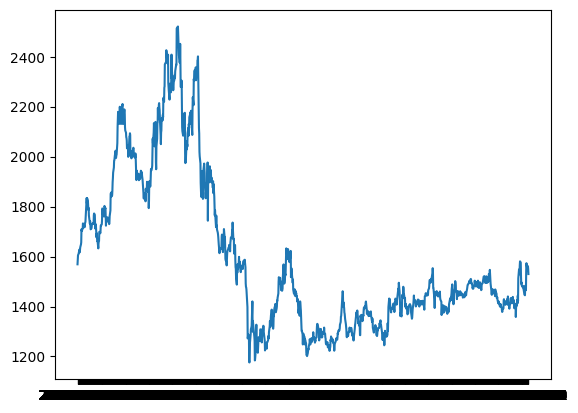

In [4]:
plt.plot(data['Date'], data['Ucome_fob_ARA']);

{'whiskers': [<matplotlib.lines.Line2D at 0x306ec7750>,
 'caps': [<matplotlib.lines.Line2D at 0x306ec79d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x306ec7610>],
 'medians': [<matplotlib.lines.Line2D at 0x306ec7c50>],
 'fliers': [<matplotlib.lines.Line2D at 0x306ec7d90>],
 'means': []}

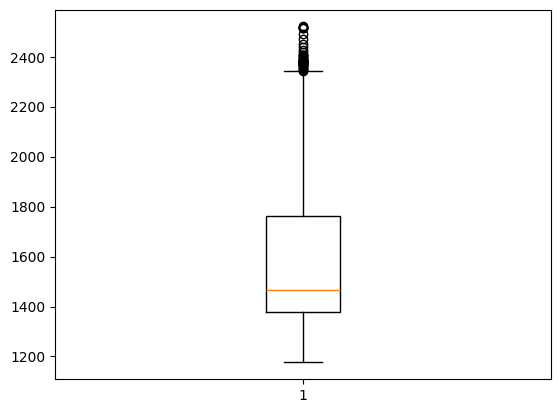

In [5]:
plt.boxplot(data['Ucome_fob_ARA'])

# Model Training Example

In [6]:
# Split first, then fit scaler/selector on train only
train_selected, test_selected, selected_cols = split_scale_feature_select(scaler_type='MinMax')
scaled_data = pd.concat([train_selected, test_selected], ignore_index=True)
scaled_data.head()

Calculating Indicators for HVO_class_II_fob_ARA
Calculating Indicators for Ucome_fob_ARA
Calculating Indicators for UCO_exw_ARA
Calculating Indicators for EU_BRENT_CRUDE
Calculating Indicators for LSMGO_Rotterdam

All 26 technical indicators calculated successfully!

Indicators added (130) total columns:

DataFrame shape: (1824, 139)


,HVO_class_II_fob_ARA,UCO_exw_ARA,LSMGO_Rotterdam,EUR_USD_rate,Rate,HVO_class_II_fob_ARA_SMA_20,HVO_class_II_fob_ARA_SMA_50,HVO_class_II_fob_ARA_EMA_12,HVO_class_II_fob_ARA_EMA_26,HVO_class_II_fob_ARA_KAMA_10,...,LSMGO_Rotterdam_CTI_20,LSMGO_Rotterdam_MACD_Histogram,LSMGO_Rotterdam_TRIX,LSMGO_Rotterdam_PPO,LSMGO_Rotterdam_Coppock_Curve,LSMGO_Rotterdam_KST,LSMGO_Rotterdam_BB_Upper,LSMGO_Rotterdam_DMA_20_50,LSMGO_Rotterdam_MAD_20,Ucome_fob_ARA
0,0.237455,0.334380,0.005848,0.045253,0.003788,0.219194,0.225254,0.220168,0.221523,0.224211,...,0.496945,0.430584,0.393419,0.298720,0.245398,0.250586,0.004513,0.31743,0.0,0.319313
1,0.239630,0.341986,0.014035,0.039485,0.001894,0.221144,0.227345,0.222459,0.223693,0.226114,...,0.496945,0.432439,0.390038,0.302443,0.245398,0.250586,0.011439,0.31743,0.0,0.320606
2,0.237574,0.333065,0.008187,0.066105,0.000000,0.221877,0.228131,0.223218,0.224471,0.226829,...,0.496945,0.430887,0.375027,0.302107,0.245398,0.250586,0.010481,0.31743,0.0,0.322525
3,0.239809,0.332697,0.010136,0.067214,0.000631,0.222762,0.229080,0.224287,0.225474,0.227692,...,0.496945,0.430442,0.362073,0.302497,0.245398,0.250586,0.010331,0.31743,0.0,0.325947
4,0.242044,0.332328,0.012086,0.068323,0.001263,0.223733,0.230121,0.225557,0.226620,0.228640,...,0.496945,0.430582,0.352317,0.303391,0.245398,0.250586,0.010673,0.31743,0.0,0.329369


In [7]:
target_col = scaled_data['Ucome_fob_ARA']

In [8]:
# Use leakage-safe outputs from split_scale_feature_select (Cell 7)
# Do NOT run feature selection again on combined train+test.

# Update the number of features after train-only feature selection
n_features = train_selected.shape[1]  # includes target column

# Use the pre-split selected sets directly
train_data = train_selected.copy()
test_data = test_selected.copy()

# Prepare the data for the neural network
window_size = 30
lookahead_value = 10
batch_size = 32

In [9]:
windowed_train = window_creator(train_data, window_size, lookahead_value, batch_size)

windowed_test = window_creator(test_data, window_size, lookahead_value, batch_size)

# Linear Models Evaluation

In [20]:
from src.models.linear_models import run_linear_models_experiment

In [21]:
raw_data = technical_indicator_creation().copy()

# Use the exact RF-selected feature subset
feature_cols = [c for c in selected_cols if c in raw_data.columns]

linear_results_df, linear_artifacts = run_linear_models_experiment(
    data=raw_data,
    target_col='Ucome_fob_ARA',
    feature_cols=feature_cols,
    horizon=1,
    target_mode='level',
    start_date='2023-01-01',
    train_size=0.70,
    val_size=0.15,
)

print(f"Using {len(feature_cols)} selected features in linear models.")
linear_results_df

linear_results_df = linear_results_df[linear_results_df['model'] != 'Linear Regression'].reset_index(drop=True)
linear_results_df

Calculating Indicators for HVO_class_II_fob_ARA
Calculating Indicators for Ucome_fob_ARA
Calculating Indicators for UCO_exw_ARA
Calculating Indicators for EU_BRENT_CRUDE
Calculating Indicators for LSMGO_Rotterdam

All 26 technical indicators calculated successfully!

Indicators added (130) total columns:

DataFrame shape: (1824, 139)


NameError: name 'selected_cols' is not defined

In [22]:
# Optimize hyperparameters
ltsm_params = optimize_hyperparameters(
    train_df=train_data, 
    model_type='lstm',
    lookahead_value=lookahead_value, 
    batch_size=batch_size,
    window_size=window_size,
    n_features=n_features
)

gru_params = optimize_hyperparameters(
    train_df=train_data,
    model_type='gru',
    lookahead_value=lookahead_value,
    batch_size=batch_size,
    window_size=window_size,
    n_features=n_features
)

hybrid_params = optimize_hyperparameters(
    train_df=train_data, 
    model_type='hybrid',
    lookahead_value=lookahead_value, 
    batch_size=batch_size,
    window_size=window_size,
    n_features=n_features
)


NameError: name 'optimize_hyperparameters' is not defined

In [23]:
#models
ltsm_model = LSTMModel(
    lstm_units=int(hybrid_params['lstm_units']),
    dropout=float(hybrid_params['dropout']),
    learning_rate=float(hybrid_params['learning_rate']),
    window_size=window_size,
    n_features=n_features
)
gru_model = GRUModel(
    gru_units=int(hybrid_params['gru_units']),
    dropout=float(hybrid_params['dropout']),
    learning_rate=float(hybrid_params['learning_rate']),
    window_size=window_size,
    n_features=n_features
)
hybrid_model = HybridGRU_LSTM(
    gru_units=int(hybrid_params['gru_units']),
    lstm_units=int(hybrid_params['lstm_units']),
    dropout=float(hybrid_params['dropout']),
    learning_rate=float(hybrid_params['learning_rate']),
    window_size=window_size,
    n_features=n_features
)

NameError: name 'LSTMModel' is not defined

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from src.feature_engine import technical_indicator_creation

print("Training model on training set...")
history = [
    ltsm_model.train(windowed_train),
    gru_model.train(windowed_train),
    hybrid_model.train(windowed_train)
]   
print("Training complete!\n")

print("Evaluating model on test set...")
test_metrics = [ltsm_model.evaluate(windowed_test), gru_model.evaluate(windowed_test), hybrid_model.evaluate(windowed_test)]
# print(f"Test Loss (MSE, scaled): {test_metrics[0]:.6f}")
# print(f"Test MAE (scaled): {test_metrics[1]:.6f}\n")

print("Generating predictions on test set...")
predictions = [ltsm_model.predict(windowed_test).flatten(), gru_model.predict(windowed_test).flatten(), hybrid_model.predict(windowed_test).flatten()]

# Rebuild y_true from windowed_test to avoid shape/alignment mistakes
y_true_scaled = []
for _, y_batch in windowed_test:
    y_true_scaled.extend(y_batch.numpy().flatten())
y_true_scaled = pd.Series(y_true_scaled).to_numpy()
model_names = ['LSTM', 'GRU', 'Hybrid']
for i in range(3):
    print(f"\nModel {model_names[i]} Evaluation:")
    # Scaled-space metrics
    scaled_mae = mean_absolute_error(y_true_scaled, predictions[i])
    scaled_rmse = mean_squared_error(y_true_scaled, predictions[i]) ** 0.5
    scaled_r2 = r2_score(y_true_scaled, predictions[i])

    print(f"Predictions shape: {predictions[i].shape}")
    print(f"First 10 predictions:\n{predictions[i][:10]}")
    print(f"Prediction range: [{predictions[i].min():.4f}, {predictions[i].max():.4f}]")
    print(f"Scaled MAE: {scaled_mae:.6f}")
    print(f"Scaled RMSE: {scaled_rmse:.6f}")
    print(f"Scaled R2: {scaled_r2:.6f}")

    # Convert to original price units for interpretability
    raw_target = technical_indicator_creation()["Ucome_fob_ARA"].reset_index(drop=True)
    y_min = raw_target.min()
    y_max = raw_target.max()
    scale = (y_max - y_min)

    y_true_orig = y_true_scaled * scale + y_min
    y_pred_orig = predictions[i] * scale + y_min

    orig_mae = mean_absolute_error(y_true_orig, y_pred_orig)
    orig_rmse = mean_squared_error(y_true_orig, y_pred_orig) ** 0.5
    orig_r2 = r2_score(y_true_orig, y_pred_orig)

    print(f"Original-unit MAE: {orig_mae:.6f}")
    print(f"Original-unit RMSE: {orig_rmse:.6f}")
    print(f"Original-unit R2: {orig_r2:.6f}")
    print("\nModel training and evaluation complete!")

Training model on training set...


NameError: name 'ltsm_model' is not defined

In [10]:
import pickle
pickle.dump(hybrid_model, open("hybrid_model.pkl", "wb"))
pickle.dump(ltsm_model, open("ltsm_model.pkl", "wb"))
pickle.dump(gru_model, open("gru_model.pkl", "wb"))

model_filename = "hybrid_model.pkl, ltsm_model.pkl, gru_model.pkl"


print(f"Model successfully serialized and saved to {model_filename}\n")

NameError: name 'hybrid_model' is not defined

In [11]:
%load_ext autoreload
%autoreload 2

In [12]:
from src.models.neural_models import *

In [13]:
import src.models.neural_models

import importlib
importlib.reload(src.models.neural_models)
from src.models.neural_models import *


In [15]:
with open('gru_model.pkl', 'rb') as file:
    gru_data = pickle.load(file)

In [17]:
gru_predictions = gru_data.predict(windowed_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


In [20]:
targets = np.concatenate([y.numpy() for x, y in windowed_test], axis=0)

In [49]:
dates = pd.date_range('2021-04-26', '2026-04-23')
training_dates = dates[81:len(dates)-len(targets)]
test_dates = dates[len(dates)-len(targets):]

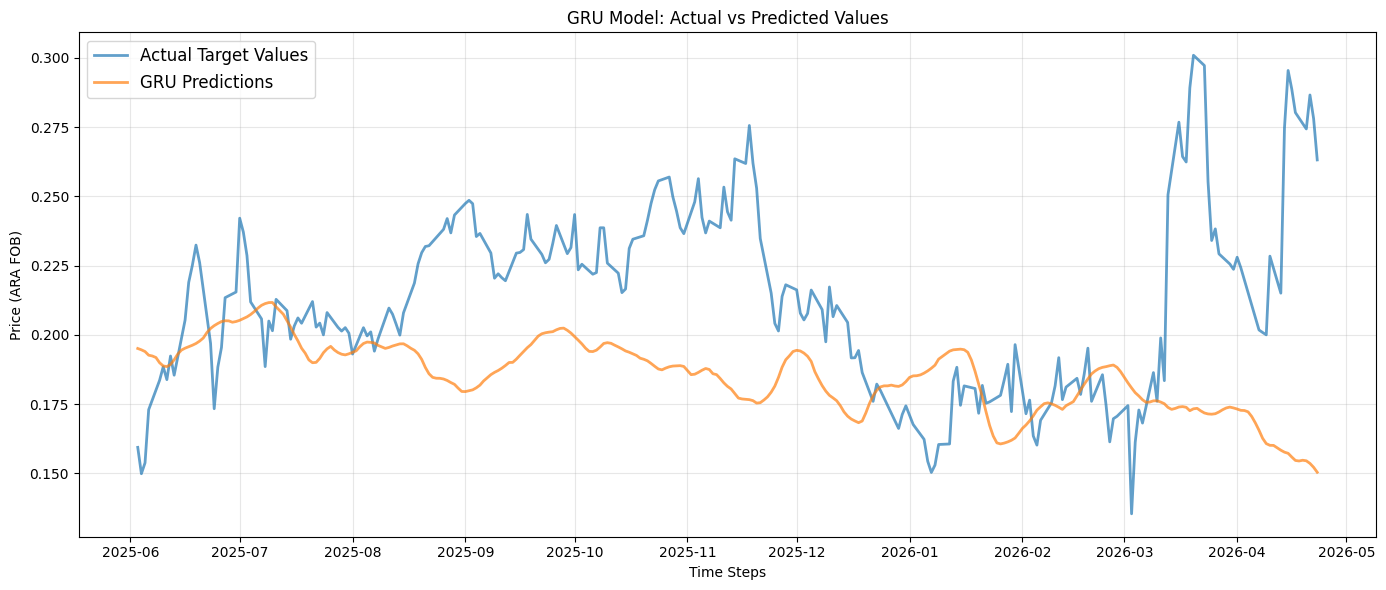

In [51]:
# Create figure and plot
plt.figure(figsize=(14, 6))
plt.plot(test_dates, targets, label='Actual Target Values', linewidth=2, alpha=0.7)
plt.plot(test_dates, gru_predictions, label='GRU Predictions', linewidth=2, alpha=0.7)

plt.xlabel('Time Steps')
plt.ylabel('Price (ARA FOB)')
plt.title('GRU Model: Actual vs Predicted Values')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


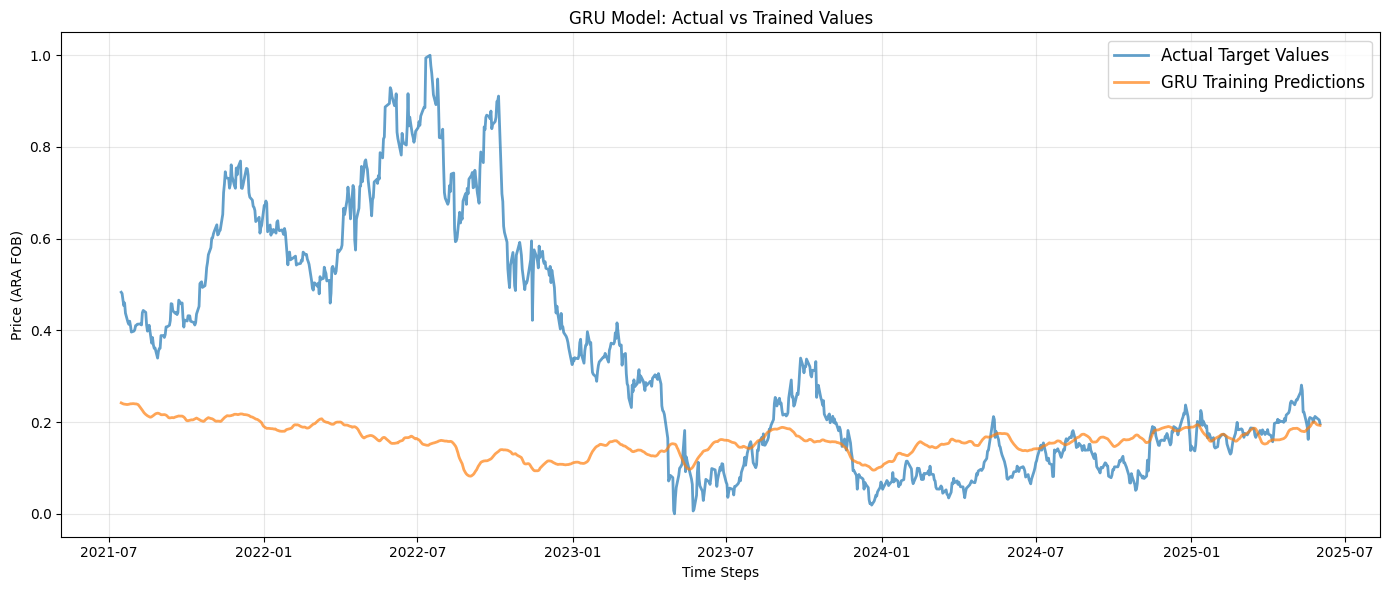

In [52]:
# Create figure and plot
plt.figure(figsize=(14, 6))
plt.plot(training_dates, np.concatenate([y.numpy() for x, y in windowed_train], axis=0), label='Actual Target Values', linewidth=2, alpha=0.7)
plt.plot(training_dates, gru_data.predict(windowed_train), label='GRU Training Predictions', linewidth=2, alpha=0.7)

plt.xlabel('Time Steps')
plt.ylabel('Price (ARA FOB)')
plt.title('GRU Model: Actual vs Trained Values')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()